In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector, SetDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

# Defining Global Variables

In [3]:
x_star = 1/3 * (-2 + np.cbrt(19-3*np.sqrt(33)) + np.cbrt(19+3*np.sqrt(33)))
theta = np.arcsin(x_star)

# Graphing Settings

In [ ]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Importing Data

In [5]:
data1 = np.load("depolarizing_error_rates.npz")
data2 = np.load("convergence_axis_error_rates.npz")

depolarizing_input_error_rate = data1["input_error_rate_list"]
depolarizing_output_error_rate = data1["output_error_rate"]
depolarizing_intersection = data1["intersection"]
convergence_axis_input_error_rate = data2["input_error_rate_list"]
convergence_axis_output_error_rate = data2["output_error_rate"]
convergence_axis_intersection = data2["intersection"]

# Plots

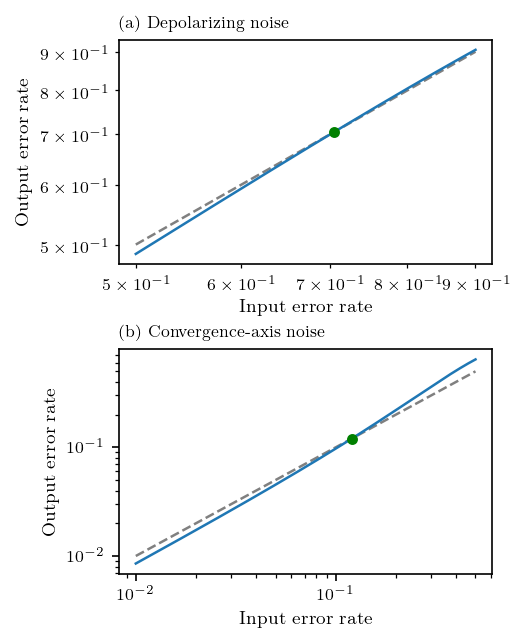

In [ ]:
dep_x_intersect = depolarizing_intersection
dep_y_intersect = depolarizing_intersection

conv_x_intersect = convergence_axis_intersection
conv_y_intersect = convergence_axis_intersection

column_width = 3.4

fig, axes = plt.subplots(
    2, 1,
    figsize=(column_width, 4.2),
    sharex=False,
    sharey=False
)

# --- Plot 1: depolarizing noise ---
ax = axes[0]

ax.plot(
    depolarizing_input_error_rate,
    depolarizing_input_error_rate,
    color="gray",
    linestyle="--"
)

ax.plot(
    depolarizing_input_error_rate,
    depolarizing_output_error_rate
)

ax.scatter(
    depolarizing_intersection,
    depolarizing_intersection,
    color="green",
    s=18,
    zorder=5
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Input error rate")
ax.set_ylabel("Output error rate")
ax.set_title(r"(a) Depolarizing noise", loc="left", fontsize=8)


# --- Plot 2: convergence-axis noise ---
ax = axes[1]

ax.plot(
    convergence_axis_input_error_rate,
    convergence_axis_input_error_rate,
    color="gray",
    linestyle="--"
)

ax.plot(
    convergence_axis_input_error_rate,
    convergence_axis_output_error_rate
)

ax.scatter(
    convergence_axis_intersection,
    convergence_axis_intersection,
    color="green",
    s=18,
    zorder=5
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Input error rate")
ax.set_ylabel("Output error rate")
ax.set_title(r"(b) Convergence-axis noise", loc="left", fontsize=8)

plt.tight_layout(pad=0.5)

plt.show()